Episode 10 Reward: -116
Episode 200 Reward: 90
Episode 800 Reward: 93


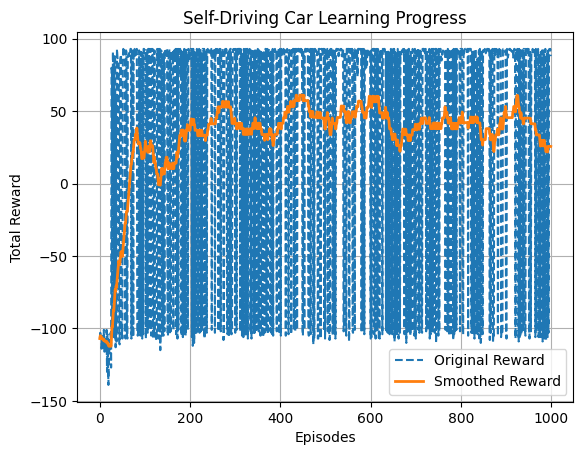


Optimal Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]

Grid Visualization:

S . . . .
* X . X .
* * * * *
X . X . *
. . . . D

Final Q-Table:


State (0,0):
  Up: 37.14
  Down: 42.61
  Left: 37.27
  Right: 31.97

State (0,1):
  Up: 5.02
  Down: -56.95
  Left: -2.27
  Right: 43.63

State (0,2):
  Up: 7.50
  Down: 53.86
  Left: -1.16
  Right: -1.49

State (0,3):
  Up: -1.22
  Down: -27.10
  Left: -1.23
  Right: -1.16

State (0,4):
  Up: -0.84
  Down: 12.53
  Left: -1.01
  Right: -0.76

State (1,0):
  Up: 36.93
  Down: 48.46
  Left: 42.43
  Right: -99.73

State (1,1):
  Up: 0.00
  Down: 0.00
  Left: 0.00
  Right: 0.00

State (1,2):
  Up: 4.31
  Down: 62.16
  Left: -34.39
  Right: -34.39

State (1,3):
  Up: 0.00
  Down: 0.00
  Left: 0.00
  Right: 0.00

State (1,4):
  Up: 0.03
  Down: 77.48
  Left: -34.39
  Right: 6.52

State (2,0):
  Up: 41.84
  Down: -99.36
  Left: 47.99
  Right: 54.95

State (2,1):
  Up: -99.29
  Down: 42.25
  Left: 47.73
  Right: 62.17


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Grid size
grid_size = 5

# Actions
actions = ['Up', 'Down', 'Left', 'Right']

# Q-table
Q = np.zeros((grid_size, grid_size, len(actions)))

# Environment
start = (0, 0)
destination = (4, 4)
obstacles = [(1,1), (1,3), (3,0), (3,2)]

# Parameters
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 1000

# Store rewards
rewards_per_episode = []

# Move function
def get_next_state(state, action):
    x, y = state

    if action == 'Up':
        x = max(0, x-1)
    elif action == 'Down':
        x = min(grid_size-1, x+1)
    elif action == 'Left':
        y = max(0, y-1)
    elif action == 'Right':
        y = min(grid_size-1, y+1)

    return (x, y)

# Reward function
def get_reward(state):
    if state in obstacles:
        return -100
    elif state == destination:
        return 100
    else:
        return -1

# ---------------- TRAINING ----------------
for episode in range(episodes):
    state = start
    total_reward = 0

    while state != destination:
        x, y = state

        # Exploration vs Exploitation
        if random.uniform(0,1) < epsilon:
            action_index = random.randint(0,3)
        else:
            action_index = np.argmax(Q[x, y])

        action = actions[action_index]
        next_state = get_next_state(state, action)
        reward = get_reward(next_state)

        total_reward += reward

        nx, ny = next_state

        # Q-learning update
        Q[x, y, action_index] += alpha * (
            reward + gamma * np.max(Q[nx, ny]) - Q[x, y, action_index]
        )

        # Stop if obstacle
        if next_state in obstacles:
            break

        state = next_state

    rewards_per_episode.append(total_reward)

    # Print important episodes
    if episode == 10:
        print("Episode 10 Reward:", total_reward)
    if episode == 200:
        print("Episode 200 Reward:", total_reward)
    if episode == 800:
        print("Episode 800 Reward:", total_reward)

# ---------------- CLEAR GRAPH ----------------
window = 50
smoothed_rewards = []

for i in range(len(rewards_per_episode)):
    smoothed_rewards.append(
        np.mean(rewards_per_episode[max(0, i-window):(i+1)])
    )

plt.figure()

# Original rewards (dashed line)
plt.plot(rewards_per_episode, linestyle='dashed', label='Original Reward')

# Smoothed rewards (main learning curve)
plt.plot(smoothed_rewards, linewidth=2, label='Smoothed Reward')

plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Self-Driving Car Learning Progress")

plt.legend()
plt.grid()

plt.show()

# ---------------- TEST PATH ----------------
state = start
path = [state]

while state != destination:
    x, y = state
    action_index = np.argmax(Q[x, y])
    action = actions[action_index]
    state = get_next_state(state, action)
    path.append(state)

print("\nOptimal Path:", path)

# ---------------- GRID VISUALIZATION ----------------
grid = np.full((grid_size, grid_size), ".")

for obs in obstacles:
    grid[obs] = "X"

for step in path:
    grid[step] = "*"

grid[start] = "S"
grid[destination] = "D"

print("\nGrid Visualization:\n")
for row in grid:
    print(" ".join(row))

# ---------------- Q-TABLE ----------------
print("\nFinal Q-Table:\n")

for i in range(grid_size):
    for j in range(grid_size):
        print(f"\nState ({i},{j}):")
        for k in range(4):
            print(f"  {actions[k]}: {Q[i,j,k]:.2f}")